# Initial Wingbeat by a Single Bird

Bird used will be Rhaegal, who is flying 9m flights without an obstacle or any weights. Data looks at just the first wingbeat of the flight.



In [2]:
%config InlineBackend.figure_format='retina'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from pydmd import DMD
from pydmd.bopdmd import BOPDMD
from pydmd.plotter import plot_eigs
from pydmd.plotter import plot_summary
from pydmd.preprocessing.hankel import hankel_preprocessing

/var/folders/2m/t5bb62r50jbb_r1gf5dsdy680000gr/T/ipykernel_91478/837444830.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Loading Data 

Contains 28 columns: the `x,y,z` position of 8 markers on the bird's wings and tail. Also includes `time`, `sequence ID`, and `frameID` information, plus the overall horizontal position `HorzDistance` of the bird with respect to the final perch. 

Data stored as a numpy array and another array is saved with the column names. 

In [123]:

# Within this file are two numpy arrays -- one which contains just the initial 
# wingbeat and another which contains all the wingbeats from the flapping portion of the flight. 

data = np.load("../../data/samples/toothless_12m_flightmodes.npz", allow_pickle=True)
wingbeat_data = data['initial']

print("Initial wingbeat numpy size: ", wingbeat_data.shape)

# Can create a pandas dataframe of the data to make sure the columns are labeled correctly
columns = np.load("../../data/samples/marker_column_names.npy",allow_pickle=True)
wingbeat_df = pd.DataFrame(wingbeat_data, columns=columns)

# Inspect the new dataframe. 
wingbeat_df.head()



Initial wingbeat numpy size:  (6801, 28)


,time,frameID,HorzDistance,Seq,left_wingtip_x,left_wingtip_y,left_wingtip_z,left_primary_x,left_primary_y,left_primary_z,...,right_wingtip_z,right_primary_x,right_primary_y,right_primary_z,right_secondary_x,right_secondary_y,right_secondary_z,right_tailtip_x,right_tailtip_y,right_tailtip_z
0,-0.035,04_12_143_001124,11.497397,143,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.209702,0.251241,0.00045,-0.09462,0.143901,-0.122255,-0.062778,0.090613,-0.278647,0.015666
1,-0.03,04_12_101_001185,11.499332,101,0.208951,0.003934,-0.429666,0.167571,0.079852,-0.297911,...,-0.442432,0.141759,0.070774,-0.312285,0.162779,-0.106871,-0.226782,0.168439,-0.236545,-0.067568
2,-0.03,04_12_102_001062,11.489751,102,0.15248,-0.038254,-0.324256,0.17808,0.061003,-0.205948,...,-0.341136,0.15923,0.066504,-0.218544,0.13733,-0.080997,-0.150016,0.17032,-0.237155,-0.075492
3,-0.03,04_12_104_000222,11.496406,104,0.211233,0.012441,-0.429597,0.169396,0.088253,-0.297593,...,-0.442558,0.138162,0.066642,-0.31304,0.155072,-0.107314,-0.23058,0.170942,-0.227893,-0.085945
4,-0.03,04_12_105_000893,11.494839,105,0.173116,0.000276,-0.396479,0.164486,0.091511,-0.266255,...,-0.41156,0.121604,0.061542,-0.287022,0.126914,-0.108058,-0.207529,0.156524,-0.233087,-0.102382


## Plotting the Data

In [ ]:
marker_column_names = ["right_wingtip_x", "right_wingtip_y", "right_wingtip_z",
                      "right_primary_x", "right_primary_y", "right_primary_z",
                      "right_secondary_x", "right_secondary_y", "right_secondary_z",
                      "right_tailtip_x", "right_tailtip_y", "right_tailtip_z",
                      "left_wingtip_x", "left_wingtip_y", "left_wingtip_z",
                      "left_primary_x", "left_primary_y", "left_primary_z",
                      "left_secondary_x", "left_secondary_y", "left_secondary_z",
                      "left_tailtip_x", "left_tailtip_y", "left_tailtip_z"]

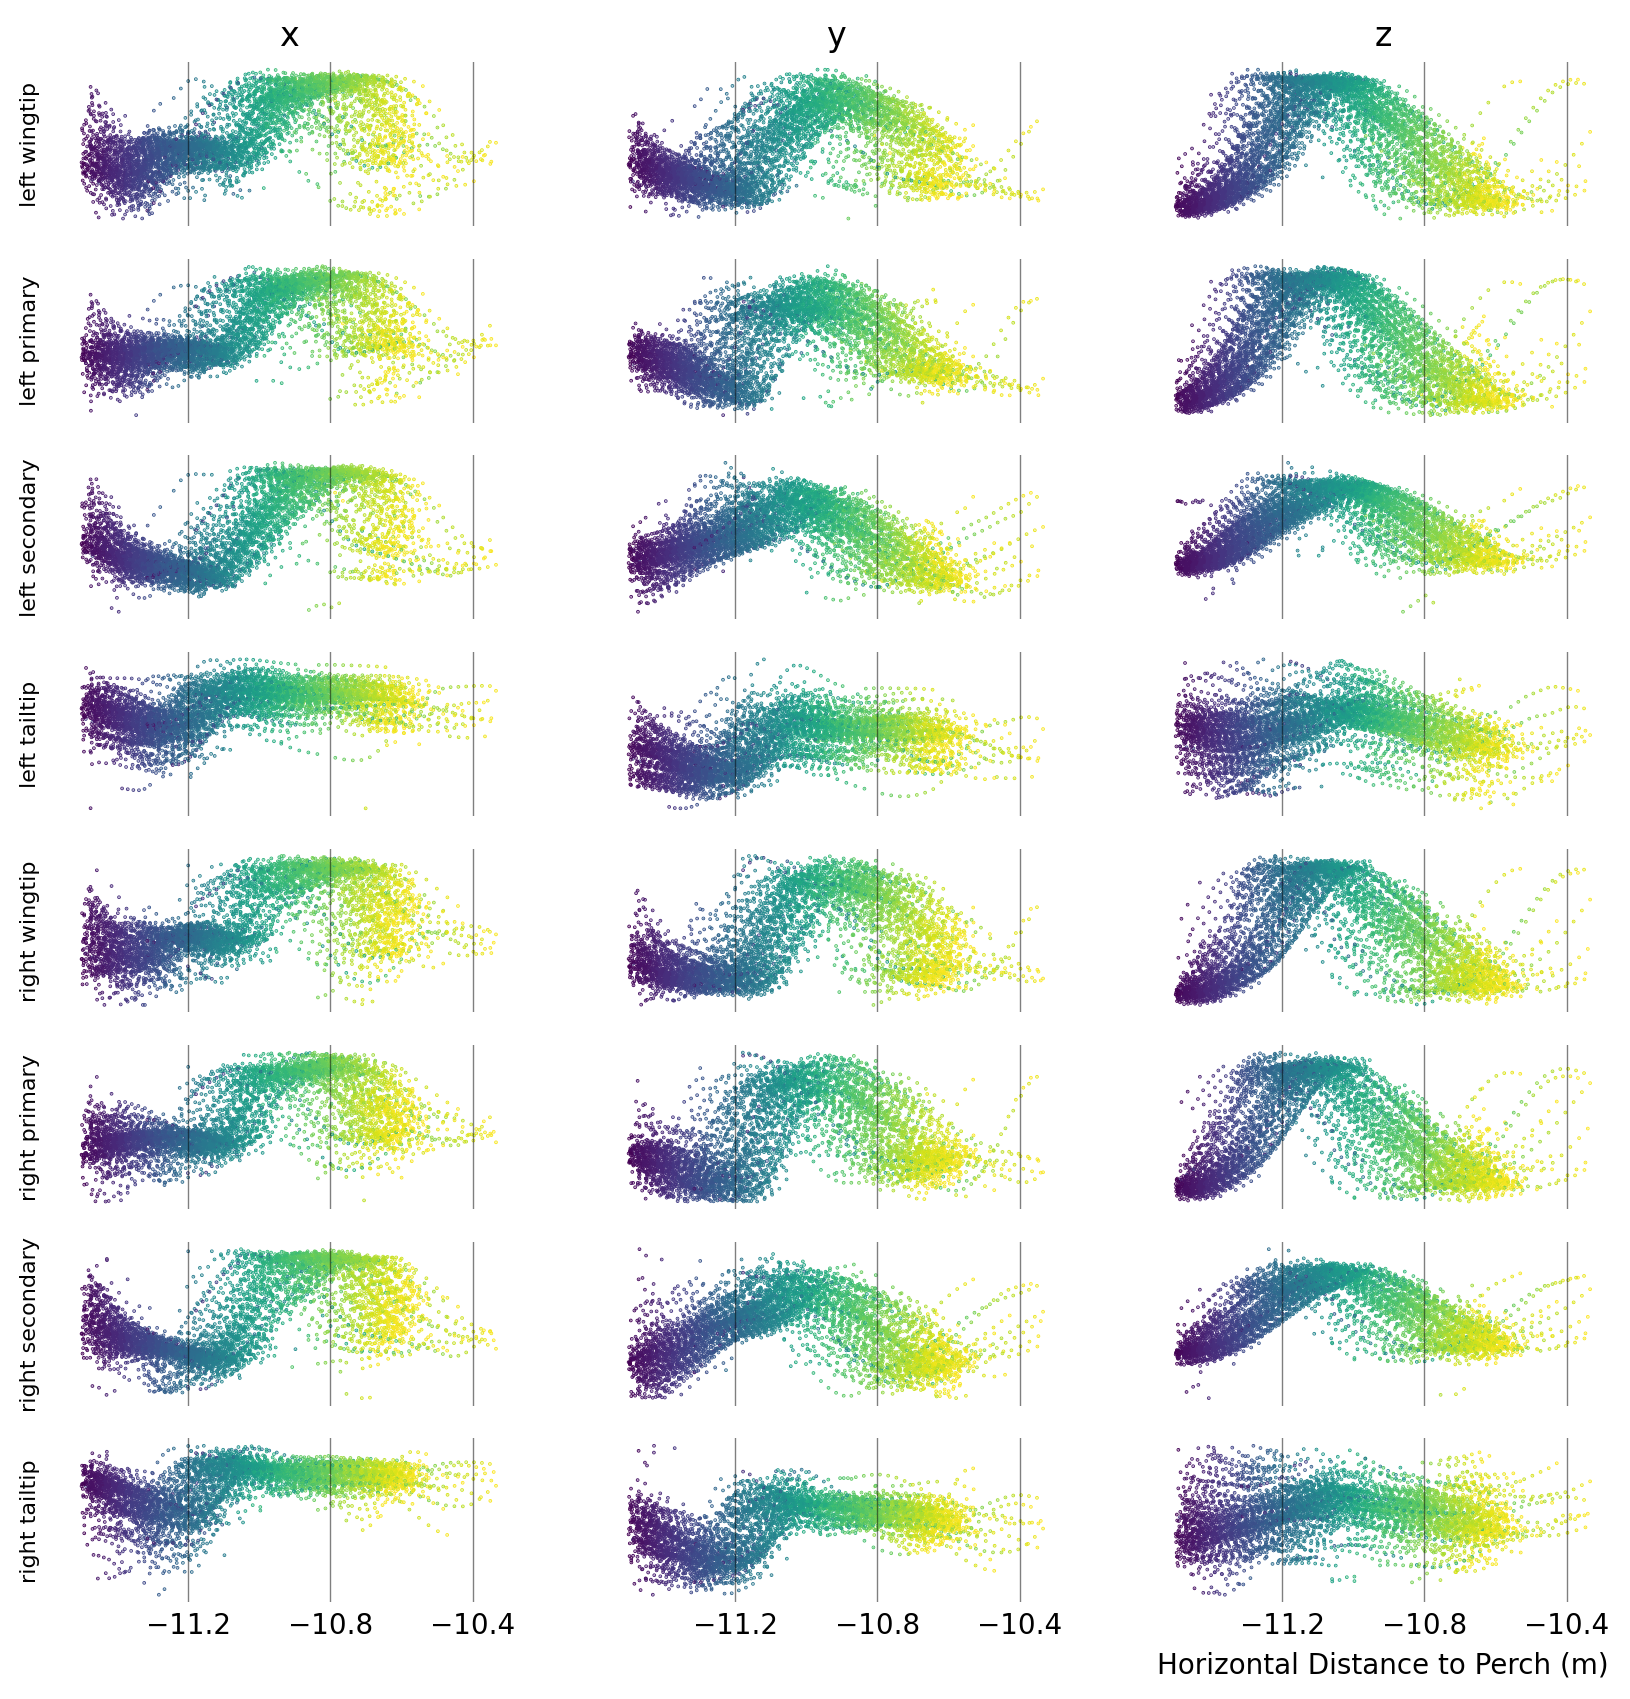

In [149]:


fig, axes = plt.subplots(8, 3, figsize=(10,10), sharex=True, sharey=False)
ax = axes.flatten()
for ii, marker in enumerate(marker_column_names):
    ax[ii].scatter(-wingbeat_df['HorzDistance'], wingbeat_df[marker], s=0.1, c=wingbeat_df['time'])
    ax[ii].grid(('on'), which='major', axis='x', linestyle='-', linewidth=0.5, color='k', alpha=0.5)

    # turn off the x axis for all but the last plot
    # Make sure there are only 3 ticks
    ax[ii].xaxis.set_major_locator(plt.MaxNLocator(4))
    
    # For every 3rd plot, label the y axis
    if ii % 3 == 0:
        ax[ii].set_ylabel(marker.split('_')[0] + " " + marker.split('_')[1], fontsize=8)

    if ii < 23:
        pass
    else:
        ax[ii].set_xlabel('Horizontal Distance to Perch (m)')
        
    # Turn off the y axis for all and the y labels
    ax[ii].yaxis.set_ticklabels([])

    # Turn off box
    ax[ii].spines['top'].set_visible(False)
    ax[ii].spines['right'].set_visible(False)
    ax[ii].spines['left'].set_visible(False)
    ax[ii].spines['bottom'].set_visible(False)

    # Turn off ticks
    ax[ii].tick_params(axis='both', which='both', length=0)

ax[0].title.set_text('x')
ax[1].title.set_text('y')
ax[2].title.set_text('z')



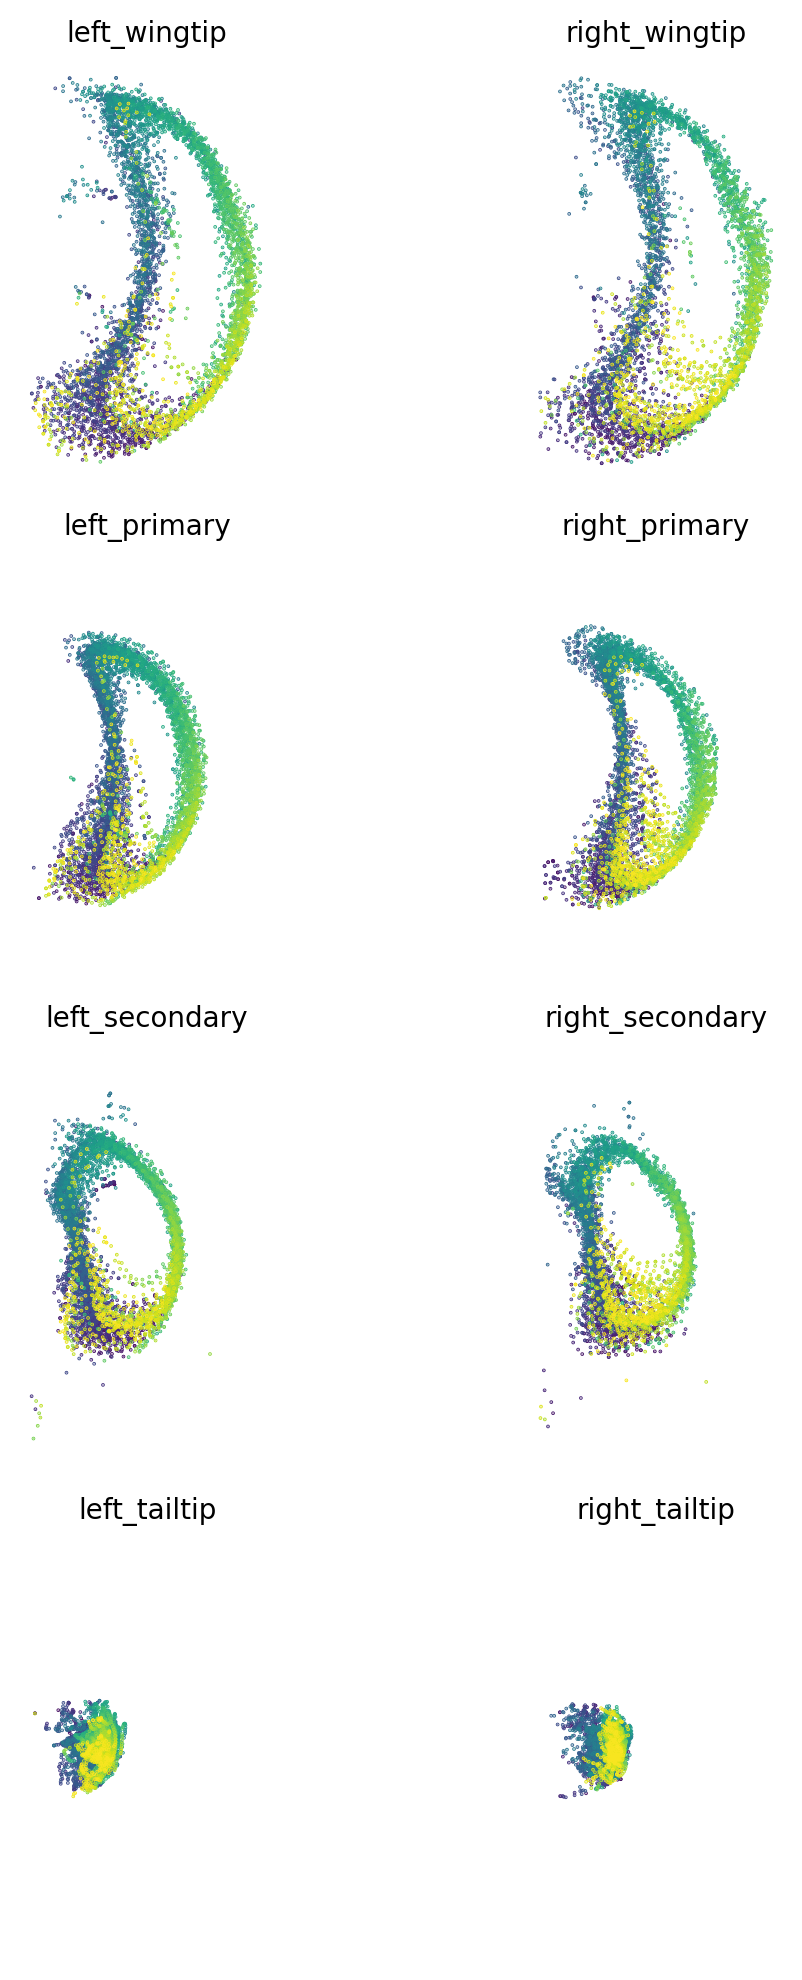

In [125]:
marker_names_for_fig = ["left_wingtip",  "right_wingtip", 
                        "left_primary",  "right_primary",  
                        "left_secondary", "right_secondary",  
                        "left_tailtip", "right_tailtip"]

fig, axes = plt.subplots(4,2, figsize=(10,10), sharex=True, sharey=True, tight_layout=True)
ax = axes.flatten()
for ii, marker in enumerate(marker_names_for_fig):

    ax[ii].scatter(wingbeat_df[marker+"_x"], wingbeat_df[marker+"_z"], s=0.1, c=wingbeat_df['time'])
    ax[ii].set_aspect('equal','box')
    
    # Turn off axis
    ax[ii].axis('off')

    ax[ii].set_title(marker, fontsize=10)



# Check nans

Not all sequences have a complete set of points. Ensuring those with too few points are excluded is critical for comparing across many sequences. 

Number of sequences:  177
Number of sequences with less than 25 nans:  21


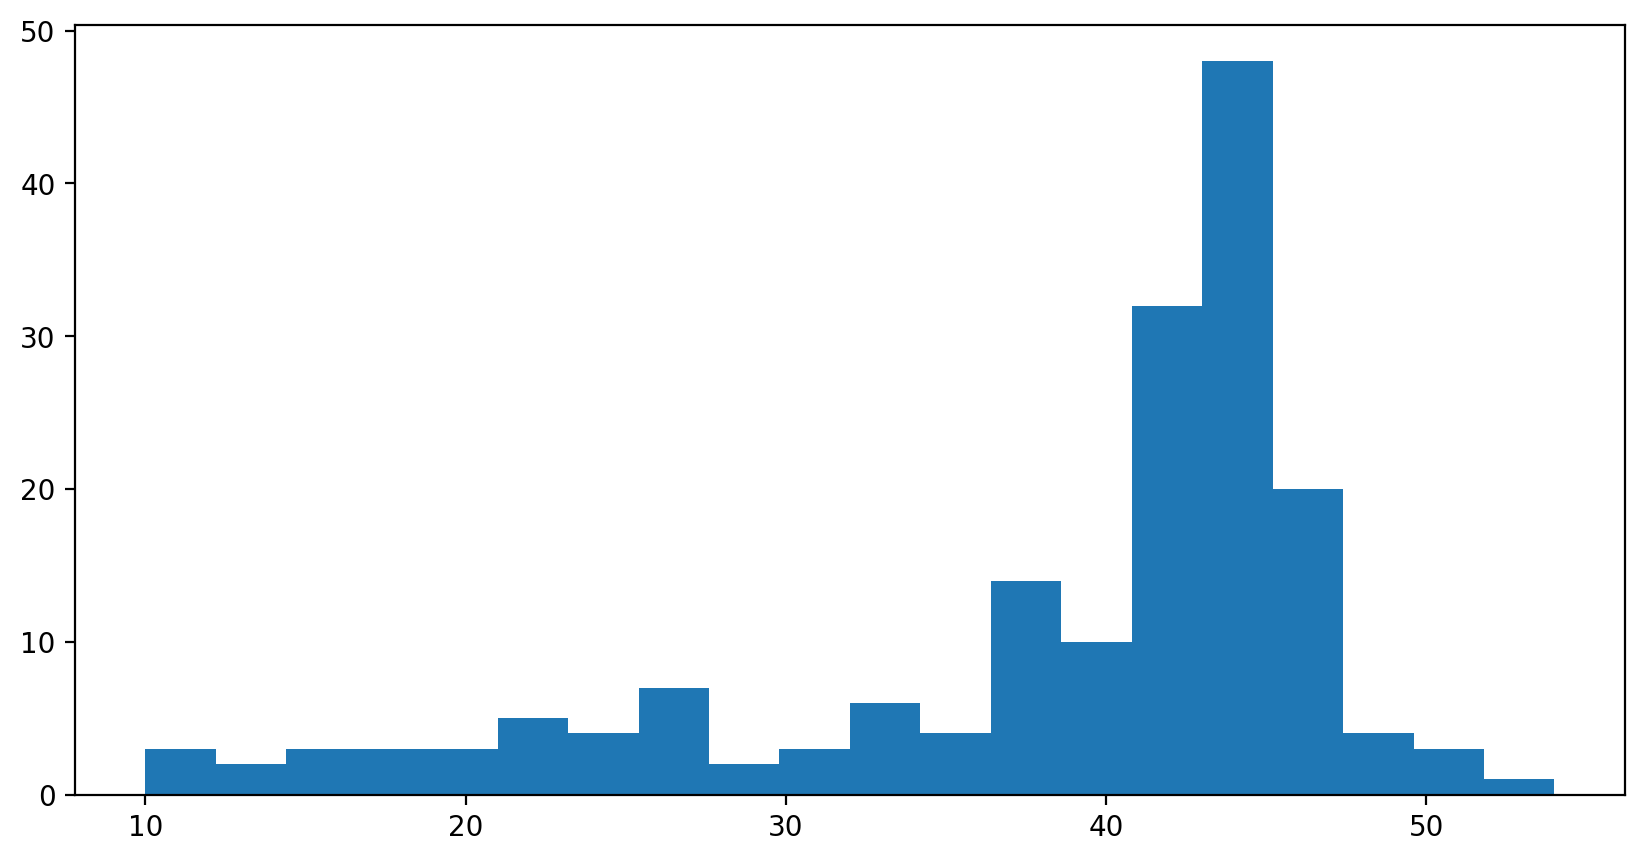

In [126]:
# Make a histogram of the number of nans in the frameID column per sequence
# This will give us an idea of how many frames are missing in each sequence
unique_sequenceIDs = wingbeat_df['Seq'].unique()

nan_counter = []
frame_counter = []
for ii in unique_sequenceIDs:
    # Count the number of nans in the frameID column
    nans = wingbeat_df[wingbeat_df['Seq'] == ii]['frameID'].isna().sum()
    not_nans = wingbeat_df[wingbeat_df['Seq'] == ii]['frameID'].notna().sum()
    frame_counter.append(not_nans)
    
    if not_nans < 25:
        nan_counter.append(ii)

print("Number of sequences: ", len(unique_sequenceIDs))

fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.hist(frame_counter, bins=20)

# Exclude sequences with more than 15 nans
print("Number of sequences with less than 25 nans: ", len(nan_counter))


## Plot single sequence

Number of unique sequenceIDs:  177


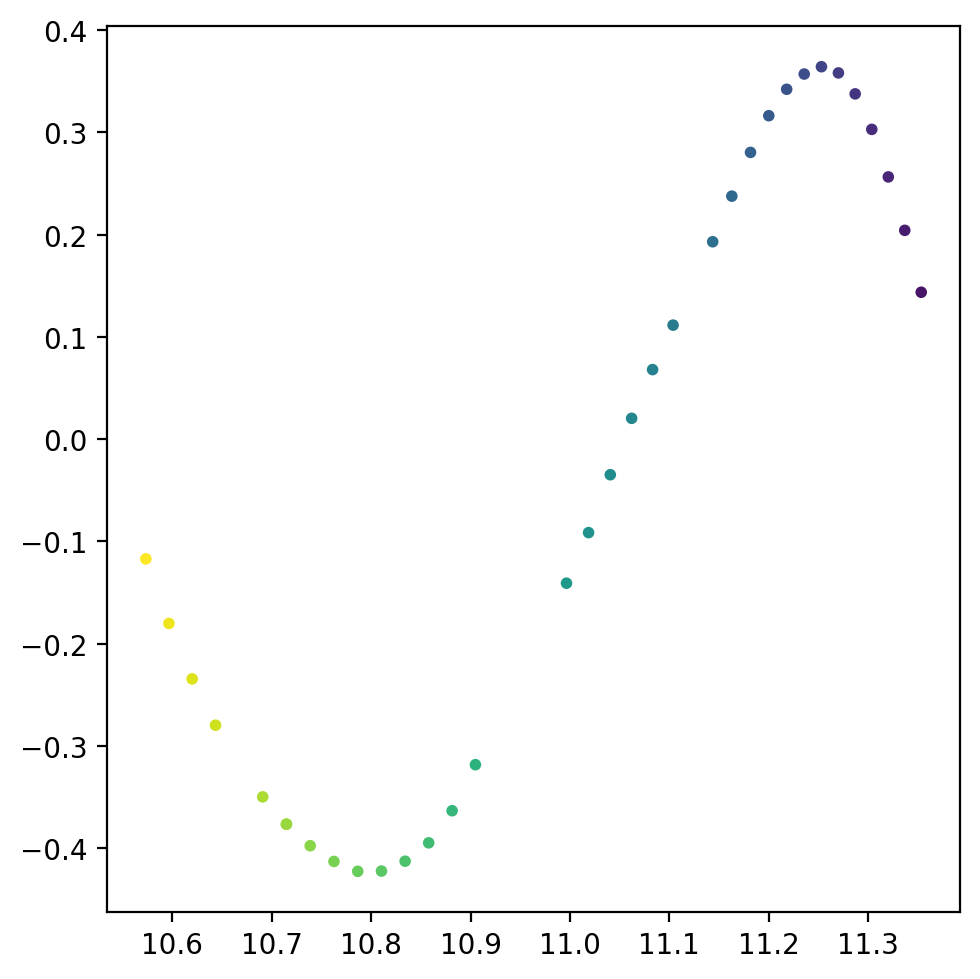

In [74]:
unique_sequenceIDs = wingbeat_df['Seq'].unique()
print("Number of unique sequenceIDs: ", len(unique_sequenceIDs))

# Plot a single sequenceID
seqID = 2
fig, ax = plt.subplots(1,1, figsize=(5,5), tight_layout=True)
ax.scatter(wingbeat_df[wingbeat_df['Seq'] == unique_sequenceIDs[seqID]]['HorzDistance'], 
           wingbeat_df[wingbeat_df['Seq'] == unique_sequenceIDs[seqID]]['right_wingtip_z'], 
           s=10, c=wingbeat_df[wingbeat_df['Seq'] == unique_sequenceIDs[seqID]]['time'])

## Create Adjusted Time 

If running DMD on each sequence concurrently, produce an adjusted time array that spaces out each sequence starting just after the previous. 

0.1975


(0.0, 1.0)

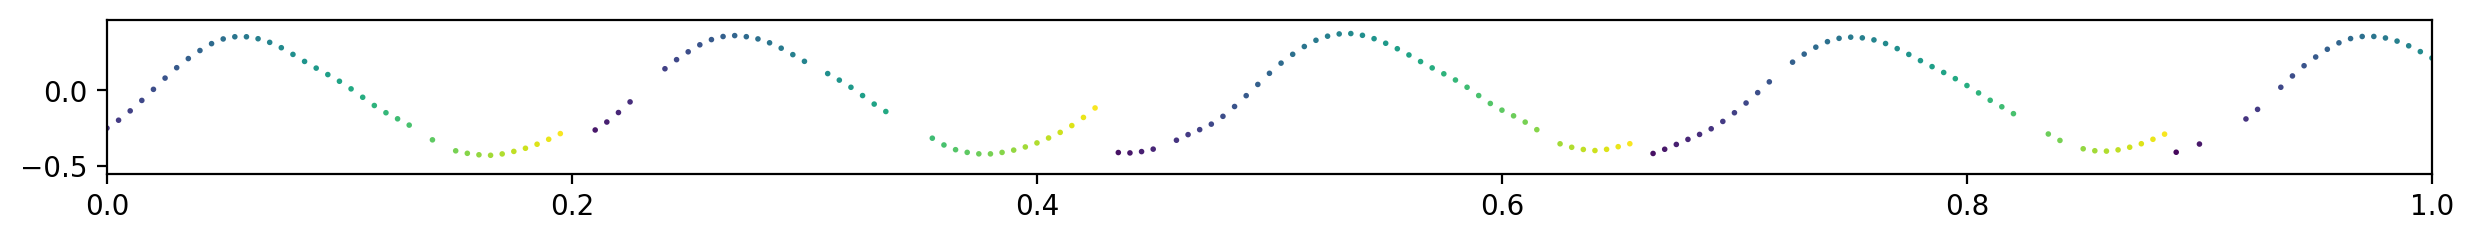

In [138]:

# Make an adjusted time column using an offset between each sequence

wingbeat_df.sort_values(by=['Seq', 'time'], inplace=True)
wingbeat_df['adjusted_time'] = wingbeat_df['time']

# Find the duration of the longest sequence
print(max(abs(wingbeat_df['adjusted_time']))+min(abs(wingbeat_df['adjusted_time'])))

unique_sequenceIDs = wingbeat_df['Seq'].unique()
offset = 0
for seq_id in unique_sequenceIDs:

    # Adjust time for the current sequence
    wingbeat_df.loc[wingbeat_df['Seq'] == seq_id, 'adjusted_time'] += offset

    offset = offset + 0.23

# Simple plot
fig, ax = plt.subplots(1,1, figsize=(15,1))
ax.scatter(wingbeat_df['adjusted_time'], wingbeat_df['right_wingtip_z'], s=1, c=wingbeat_df['time'])

# Uncomment this if wanting to see a few sequences
ax.set_xlim(0,1)


In [139]:

# Remove duplicated times
duplicated_times = wingbeat_df[wingbeat_df.duplicated(subset=['adjusted_time'], keep=False)]['frameID']
print(len(duplicated_times))

# Remove one of the duplicated times
wingbeat_df = wingbeat_df.drop_duplicates(subset=['adjusted_time'], keep='first')

# Remember to reset the index
wingbeat_df.reset_index(drop=True, inplace=True)


# dup = wingbeat_df[wingbeat_df['frameID'] == '04_12_412_000717']
# print(dup[['right_wingtip_x', 'right_wingtip_y', 'right_wingtip_z', 'left_wingtip_x', 'left_wingtip_y', 'left_wingtip_z']])



2


## Run DMD on an example Sequence

In [150]:


# Collect markers of interest

markers = wingbeat_df[marker_column_names].to_numpy()
seqTime = wingbeat_df['adjusted_time'].to_numpy()

# normalise the data
markers = markers - np.mean(markers, axis=0)

# Transpose the data
markers = markers.T

print("Time shape: ", seqTime.shape)
print("Markers shape: ", markers.shape)

# Assert that the time is unique
assert len(seqTime) == len(np.unique(seqTime))





Time shape:  (6367,)
Markers shape:  (24, 6367)


## DMD

In [157]:
single_seq_markers = wingbeat_df[wingbeat_df['Seq'] == unique_sequenceIDs[2]][marker_column_names].to_numpy()
single_seq_time = wingbeat_df[wingbeat_df['Seq'] == unique_sequenceIDs[2]]['adjusted_time'].to_numpy()

# Normalise
single_seq_markers = single_seq_markers - np.mean(single_seq_markers, axis=0)

# Transpose
single_seq_markers = single_seq_markers.T


delay_optdmd = hankel_preprocessing(BOPDMD(svd_rank=7, num_trials=0, eig_constraints={"imag", "conjugate_pairs"}), d=2)
delay_optdmd.fit(single_seq_markers, t=single_seq_time[1:])
plot_summary(delay_optdmd, index_modes=[1,3,5], order='F') # pick correct modes


UFuncTypeError: Cannot cast ufunc 'svd_n' input from dtype('O') to dtype('float64') with casting rule 'same_kind'

## Look at Time Dynamics


In [ ]:
# pull out time dynamics
for dynamic in delay_optdmd.dynamics:
    plt.plot(seqTime[1:], -dynamic.real)
    plt.title("Dynamics")
    plt.xlim(-0.02,1.9)
    # plt.ylim(-0.03,0.03)


    # Make the tick values every 0.08
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(0.25))
    # Draw gridlines vertical only
    plt.grid(axis='x')
plt.show()